In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [5]:
sns.set_theme(style='whitegrid')
rng = np.random.default_rng(0)


def ecdf_vs_cdf(sample, cdf, cdf_label, title, xlabel='x', ax=None, log_x=False):
    """Plot the ECDF of `sample` with a candidate CDF drawn on top."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6.5, 4))
    sns.ecdfplot(x=sample, ax=ax, label='simulation (ECDF)', lw=2)
    grid = np.linspace(np.min(sample), np.max(sample), 500)
    ax.plot(grid, cdf(grid), '--', color='crimson', lw=2, label=cdf_label)
    if log_x:
        ax.set_xscale('log')
    ax.set(xlabel=xlabel, ylabel='proportion $\\leq x$', title=title)
    ax.legend()
    return ax

### Q2

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the
distribution of the sample mean?

1. Draw n = 32 values from Uniform[-sqrt(3), sqrt(3)]; these are your data. The choice of
 ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by np.sqrt(n).
3. Repeat the above process b = 5_000 times and plot the ECDF.
4. What distribution does this approach as  increases?

 #### Answer
 - This approaches normal as we can see from the second graph. Each draw is E[0] and the variance/sd should be 1.
 - Pulling 32 numbers and taking the average gives us closer numbers to the normal distribution and they look less like the uniform distribution.
 - Repeating this 5000 times allows the graph to smooth out and visually approach the normal distribution further.

mean = -0.009   sd = 0.990


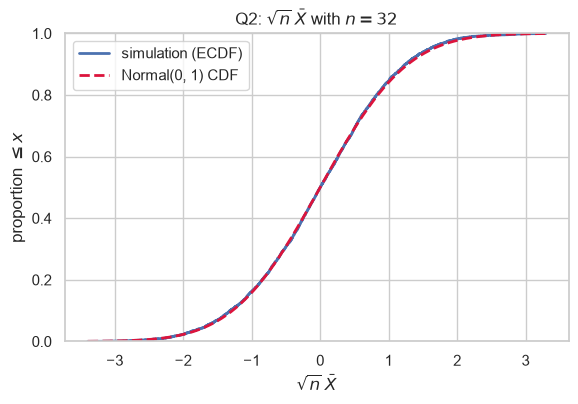

In [12]:
def simulate_scaled_mean(n, b=5_000, rng=rng):
    """b replications of sqrt(n) * mean of n Uniform[-sqrt(3), sqrt(3)] draws."""
    x = rng.uniform(-np.sqrt(3), np.sqrt(3), size=(b, n))
    return np.sqrt(n) * x.mean(axis=1)


z = simulate_scaled_mean(n=32) 
print(f'mean = {z.mean():.3f}   sd = {z.std(ddof=1):.3f}')

ecdf_vs_cdf(z, lambda g: stats.norm.cdf(g, loc=0, scale=1),
            cdf_label='Normal(0, 1) CDF',
            title='Q2: $\\sqrt{n}\\,\\bar{X}$ with $n = 32$',
            xlabel='$\\sqrt{n}\\,\\bar{X}$')
plt.show()

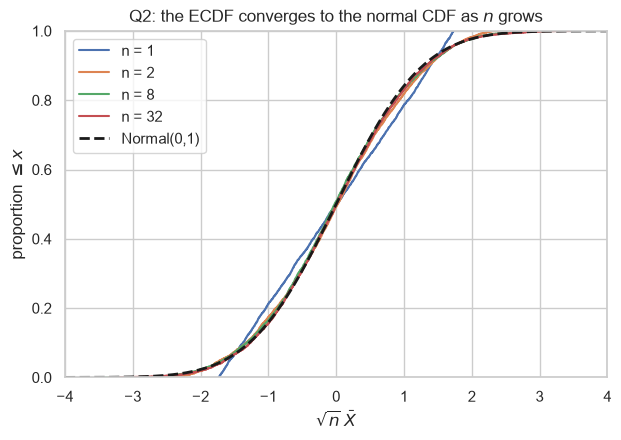

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for n in [1, 2, 8, 32]:
    sns.ecdfplot(x=simulate_scaled_mean(n), ax=ax, label=f'n = {n}')
grid = np.linspace(-4, 4, 500)
ax.plot(grid, stats.norm.cdf(grid), 'k--', lw=2, label='Normal(0,1)')
ax.set(xlim=(-4, 4), xlabel='$\\sqrt{n}\\,\\bar{X}$', ylabel='proportion $\\leq x$',
       title='Q2: the ECDF converges to the normal CDF as $n$ grows')
ax.legend()
plt.show()


#Generated with Claude so I could better show visually how the simulation compares at several sample sizes and plot ECDF against Normal(0,1) CDF
#As n grows the curves collapse onto it

### Q4.
A process is running in discrete time. In each time interval of length dt, it terminates with probability r *
dt, where r * dt < 1. This is called an arrival, death, or survival process, and is popular for modeling how
long patients live after a procedure, whether an employee quits, or the arrival of the next goal in a sportsball
match.
1. For each simulation of the process, determine the period in which termination occurs.
2. Convert periods to time by multiplying by dt.
3. Repeat the simulation n = 5_000 times and plot the ECDF, for a value of dt close to zero (e.g. dt =
1e-3).
4. What distribution does this approach as dt goes to zero?
5. How do the results change as you adjust r?

### Answer
- The distribution approaches exponential as dt approaches 0. 
- This is expected as the probability to make it past time T is P(T > t). Surviving 1 period is (1 - r * dt) which turns into (1 - r * dt)^(t/dt) as we go to time t we have to go past t/dt periods. So the survival function f(x) = (1 − r * dt)^t/dt then we take the log we get ln(f(x)) = t/dt ln(1 - r * dt) => 
    - expanding => ln(f(x)) = t/dt (-r * dt - (r * dt)^2/2 - ...)
    - multiply the t/dt leaves every term with a dt except -rt as they are all of a higher power on dt so all of those values will go to zero
    - so ln(f(x)) = ln(-r*dt) => e^-rt
- The fraction of survivng past t is e^-rt and the inverse is 1 - e^-rt

- So as we change r the shape of the curve and the mean change but it still approaches exponential.
- This still follows the idea that 1/lambda is the expected value for exponential distributions of e^lambda*x as we can see from the data.

mean survival time = 0.510   (1/r = 0.500)


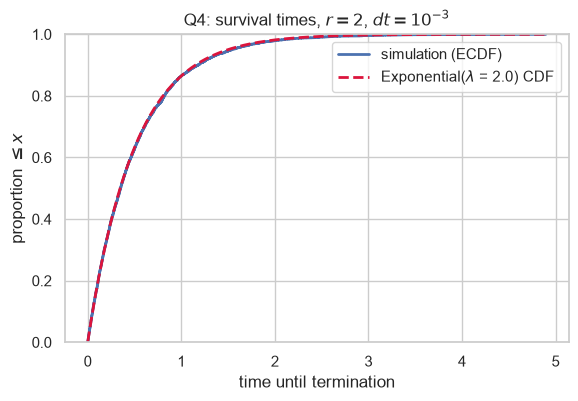

In [ ]:
def simulate_survival(r, dt, n=5_000, rng=rng):
    """n survival times from a process that terminates with prob r*dt each period of length dt."""
    assert r * dt < 1, 'need r*dt < 1 for this to be a probability' #Riemann sum of width dt and height r. Probability of termination
    periods = rng.geometric(p=r * dt, size=n)   # period in which termination occurs
    return periods * dt                         # convert periods to time / Which interval the termination of the survival goes into


def simulate_survival_loop(r, dt, n=5_000, rng=rng):
    """Same thing written out as an explicit loop, to show the mechanism."""
    times = np.empty(n)
    for i in range(n):
        period = 1
        while rng.uniform() > r * dt:
            period += 1
        times[i] = period * dt
    return times


r = 2.0 
t = simulate_survival(r=r, dt=1e-3)
print(f'mean survival time = {t.mean():.3f}   (1/r = {1/r:.3f})')

ecdf_vs_cdf(t, lambda g: stats.expon.cdf(g, scale=1/r),
            cdf_label=f'Exponential($\\lambda$ = {r}) CDF',
            title='Q4: survival times, $r = 2$, $dt = 10^{-3}$',
            xlabel='time until termination')
plt.show()

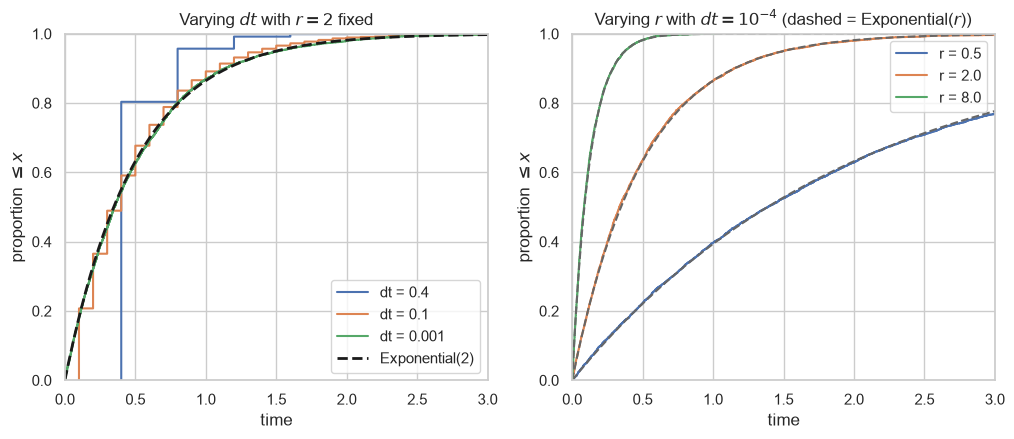

r =  0.5   sample mean = 1.982   1/r = 2.000
r =  2.0   sample mean = 0.492   1/r = 0.500
r =  8.0   sample mean = 0.125   1/r = 0.125


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

grid = np.linspace(0, 3, 500)
for dt in [0.4, 0.1, 1e-3]:
    sns.ecdfplot(x=simulate_survival(r=2.0, dt=dt), ax=axes[0], label=f'dt = {dt}')
axes[0].plot(grid, stats.expon.cdf(grid, scale=1/2.0), 'k--', lw=2, label='Exponential(2)')
axes[0].set(xlim=(0, 3), xlabel='time', ylabel='proportion $\\leq x$',
            title='Varying $dt$ with $r = 2$ fixed')
axes[0].legend()

for r_ in [0.5, 2.0, 8.0]:
    sns.ecdfplot(x=simulate_survival(r=r_, dt=1e-4), ax=axes[1], label=f'r = {r_}')
    axes[1].plot(grid, stats.expon.cdf(grid, scale=1/r_), '--', color='0.4', lw=1.5)
axes[1].set(xlim=(0, 3), xlabel='time', ylabel='proportion $\\leq x$',
            title='Varying $r$ with $dt = 10^{-4}$ (dashed = Exponential($r$))')
axes[1].legend()
plt.show()

for r_ in [0.5, 2.0, 8.0]:
    s = simulate_survival(r=r_, dt=1e-4)
    print(f'r = {r_:4.1f}   sample mean = {s.mean():.3f}   1/r = {1/r_:.3f}')

#Generated with Claude to help visualize the changes in width dt and height r

### Q5.
We're going to draw a sample of values, sort them, and track a particular rank. This is particularly useful for
understanding extreme events: We might be interested in the behavior of the biggest storm or earthquake
each year, but be working with a dataset about storms in general over 25 or 50 years.
1. Draw values from Uniform[0, 1].
2. Sort them by size from smallest to largest.
3. Record the largest value.
4. Repeat n times and plot the ECDF.
5. Repeat the previous steps for each rank from 1 to .
6. What distribution(s) does this process generate? How does the distribution depend on the rank?

### Answer
- This produces a beta distribution where a = k and b = K - k + 1. If we are using this to determine severity of extreme events, then the distribution depends on the rank as beta distribution beta(k, K - k + 1) gives the probability that a value at rank k falls between k and k+1. 

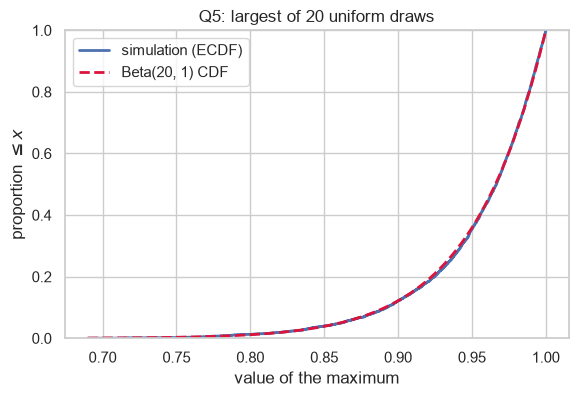

In [16]:
def simulate_order_stats(K=20, n=5_000, rng=rng):
    """Return an (n, K) array whose column k-1 holds the k-th smallest of K uniform draws."""
    return np.sort(rng.uniform(size=(n, K)), axis=1)


K = 20
order = simulate_order_stats(K=K)
largest = order[:, -1]   # rank K = the maximum

ecdf_vs_cdf(largest, lambda g: stats.beta.cdf(g, K, 1),
            cdf_label=f'Beta({K}, 1) CDF',
            title=f'Q5: largest of {K} uniform draws',
            xlabel='value of the maximum')
plt.show()

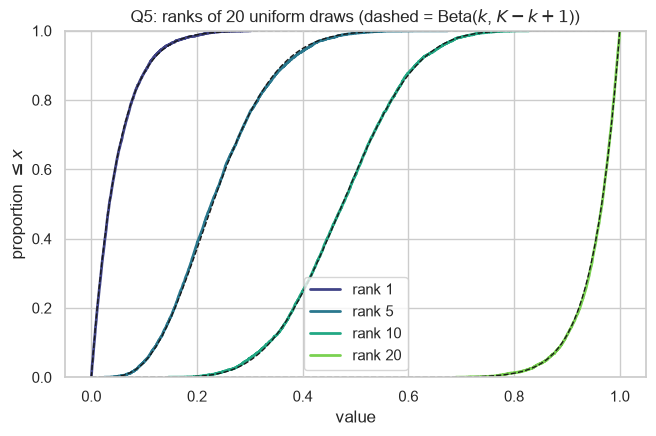

rank   sample mean    k/(K+1)
   1         0.048      0.048
   2         0.095      0.095
   3         0.143      0.143
   4         0.190      0.190
   5         0.238      0.238
   6         0.285      0.286
   7         0.332      0.333
   8         0.379      0.381
   9         0.427      0.429
  10         0.476      0.476
  11         0.523      0.524
  12         0.570      0.571
  13         0.618      0.619
  14         0.665      0.667
  15         0.713      0.714
  16         0.761      0.762
  17         0.809      0.810
  18         0.857      0.857
  19         0.904      0.905
  20         0.953      0.952


In [17]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
grid = np.linspace(0, 1, 500)
colors = sns.color_palette('viridis', 4)
for color, k in zip(colors, [1, 5, 10, 20]):
    sns.ecdfplot(x=order[:, k - 1], ax=ax, color=color, lw=2, label=f'rank {k}')
    ax.plot(grid, stats.beta.cdf(grid, k, K - k + 1), '--', color='k', lw=1)
ax.set(xlabel='value', ylabel='proportion $\\leq x$',
       title=f'Q5: ranks of {K} uniform draws (dashed = Beta($k$, $K-k+1$))')
ax.legend()
plt.show()

print(f'{"rank":>4}  {"sample mean":>12}  {"k/(K+1)":>9}')
for k in range(1, K + 1):
    print(f'{k:>4}  {order[:, k - 1].mean():>12.3f}  {k/(K+1):>9.3f}')

### Q7.
A surprising regularity appears again and again in human populations: the second-largest city is often
roughly half the size of the largest, the third-largest roughly one-third the size, and so on. This relationship is
called Zipf's law, and it connects the rank of an observation to its size.
1. Suppose there are K = 100_000 cities, ranked from largest to smallest. Create the ranks. r = {1, ..., K}
2. Zipf's law says that the size of the city with rank r is proportional to xr = (K/s)^s Start with s = 1.
3. Randomly sample n=5_000 ranks, with each rank equally likely, and record the corresponding sizes.
4. Plot the ECDF of the simulated sizes.
5. What distribution does this generate as K becomes large?
6. How does the distribution change as you adjust s?

### Answer
- As K becomes large this generates a pareto distribution. Ranks are uniform with r = {1, ..., K}. We want to see when X > x so or (K/r)^s > x from this we can get it as r < K x^-1/s as r is the random variable. 
- Then from the uniform distribution the probability that ranks r is picked is 1/K giving us r < x^-1/s = P(X > x)
- As K becomes larger the distribution smoothes out as there a are more possibilities. At K = 10 there are 10 cities and we are drawing with replacement cities of size 10/r and steps of 1/K. This only gives us 10 possible outcomes. But as K gets large like K = 100,000 steps are 1/K and there are 100,000 steps, which is finite so we use a Pareto distribution with the shape 1/s. 

- When s increases, 1/s decreases and there is a much longer tail for smaller values of b. This would imply that there are a few much larger cities pulling this distribution in that direction.

min = 1.000   median = 1.983   max = 5,556


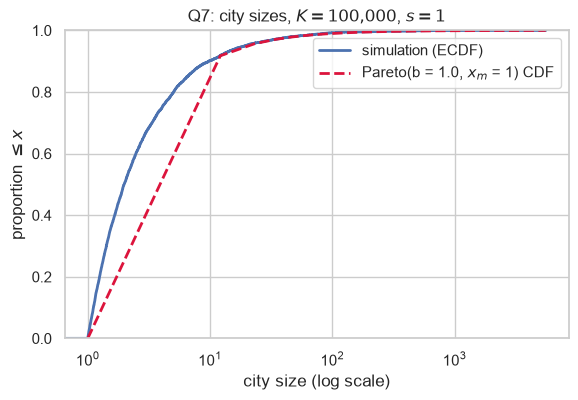

In [18]:
def simulate_zipf(K=100_000, s=1.0, n=5_000, rng=rng):
    """Sizes of n randomly chosen ranks under Zipf's law x_r = (K/r)**s."""
    ranks = rng.integers(1, K + 1, size=n)
    return (K / ranks) ** s


K, s = 100_000, 1.0
sizes = simulate_zipf(K=K, s=s)
print(f'min = {sizes.min():.3f}   median = {np.median(sizes):.3f}   max = {sizes.max():,.0f}')

ecdf_vs_cdf(sizes, lambda g: stats.pareto.cdf(g, 1/s, scale=1),
            cdf_label=f'Pareto(b = {1/s:.1f}, $x_m$ = 1) CDF',
            title='Q7: city sizes, $K = 100{,}000$, $s = 1$',
            xlabel='city size (log scale)', log_x=True)
plt.show()

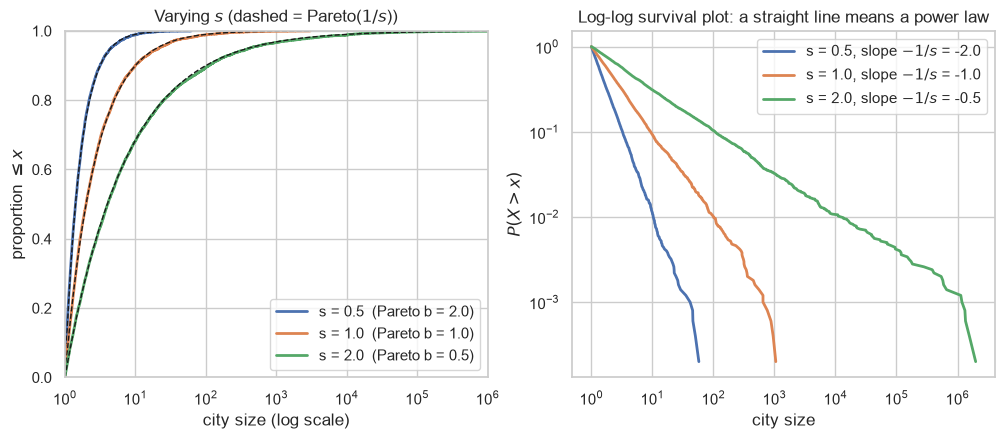

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for s_ in [0.5, 1.0, 2.0]:
    draws = simulate_zipf(K=100_000, s=s_)
    sns.ecdfplot(x=draws, ax=axes[0], lw=2, label=f's = {s_}  (Pareto b = {1/s_:.1f})')
    g = np.logspace(0, np.log10(draws.max()), 400)
    axes[0].plot(g, stats.pareto.cdf(g, 1/s_, scale=1), 'k--', lw=1)
axes[0].set(xscale='log', xlim=(1, 1e6), xlabel='city size (log scale)', ylabel='proportion $\\leq x$',
            title='Varying $s$ (dashed = Pareto($1/s$))')
axes[0].legend()

# The power-law signature: log survival function is linear in log size, with slope -1/s.
for s_ in [0.5, 1.0, 2.0]:
    draws = np.sort(simulate_zipf(K=100_000, s=s_))
    surv = 1 - np.arange(1, draws.size + 1) / draws.size
    keep = surv > 0
    axes[1].plot(draws[keep], surv[keep], lw=2, label=f's = {s_}, slope $-1/s$ = {-1/s_:.1f}')
axes[1].set(xscale='log', yscale='log', xlabel='city size', ylabel='$P(X > x)$',
            title='Log-log survival plot: a straight line means a power law')
axes[1].legend()
plt.show()

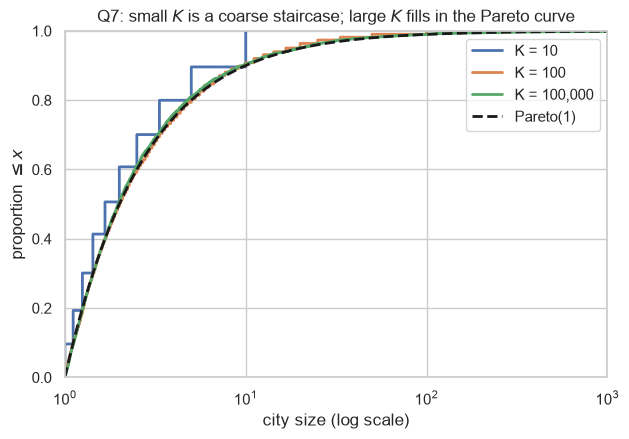

In [20]:
grid = np.logspace(0, 3, 400)
fig, ax = plt.subplots(figsize=(7, 4.5))
for K_ in [10, 100, 100_000]:
    sns.ecdfplot(x=simulate_zipf(K=K_, s=1.0), ax=ax, lw=2, label=f'K = {K_:,}')
ax.plot(grid, stats.pareto.cdf(grid, 1.0, scale=1), 'k--', lw=2, label='Pareto(1)')
ax.set(xscale='log', xlim=(1, 1e3), xlabel='city size (log scale)', ylabel='proportion $\\leq x$',
       title='Q7: small $K$ is a coarse staircase; large $K$ fills in the Pareto curve')
ax.legend()
plt.show()

### AI USE

I used claude code to help with the visualization of the different iterations. All of the markdowns explaining the distributions are my own thoughts